## 1. Imports


In [15]:
# -*- coding: utf-8 -*-
"""
Experiment script for: India
Auto-generated from merged_notebook_v3. Run independently with its own API key.
"""

from __future__ import annotations

import csv
import hashlib
import importlib
import importlib.util
import json
import math
import os
import random
import re
import time
from collections import Counter
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple


def optional_import(module_name: str):
    try:
        spec = importlib.util.find_spec(module_name)
    except ModuleNotFoundError:
        return None
    if spec is None:
        return None
    return importlib.import_module(module_name)


pd           = optional_import("pandas")
np           = optional_import("numpy")
cohere       = optional_import("cohere")
datasets_mod = optional_import("datasets")
torch        = optional_import("torch")
transformers = optional_import("transformers")
tqdm_auto    = optional_import("tqdm.auto")
plt          = optional_import("matplotlib.pyplot")
sns          = optional_import("seaborn")

try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

MISSING_OPTIONAL_PACKAGES = [
    name for name, module in {
        "pandas": pd, "numpy": np, "cohere": cohere, "datasets": datasets_mod,
        "torch": torch, "transformers": transformers, "tqdm": tqdm_auto,
        "matplotlib": plt, "seaborn": sns,
    }.items() if module is None
]

print("Optional packages missing:", MISSING_OPTIONAL_PACKAGES or "none")


Optional packages missing: none


## 2. Country Filter (One Script = One Country)


In [16]:
COUNTRY_FILTER = "India"

## 3. Paths


In [17]:
WORKDIR = Path.cwd() / "data_india"
WORKDIR.mkdir(exist_ok=True)

TEMPLATE_CSV            = WORKDIR / "cohere_experiment_sheet_india.csv"
OUTPUT_CSV              = WORKDIR / "experiment_results_india.csv"
CHECKPOINT_CSV          = WORKDIR / "experiment_checkpoint_india.csv"
TRANSLATION_CACHE_JSONL = WORKDIR / "translation_cache_india.jsonl"
TRANSLATION_QA_JSONL    = WORKDIR / "translation_qa_india.jsonl"
PARAPHRASE_CACHE_JSONL  = WORKDIR / "paraphrase_cache_india.jsonl"
RAW_CALLS_CSV           = WORKDIR / "raw_api_calls_india.csv"
RAW_RESULTS_CSV         = WORKDIR / "unaggregated_results_india.csv"

RUN_FULL_PIPELINE           = True
ENABLE_TRANSLATION_QA       = False
ENABLE_PARAPHRASE_EXTENSION = True

DRY_RUN   = False
DRY_RUN_N = 3

N_RUNS         = 5
SAVE_EVERY     = N_RUNS
TEMPERATURE    = 0.1
TOP_P          = 0.75
MAX_TOKENS     = 1024
REASONING_MAX_TOKENS = 1024
GLOBAL_RANDOM_SEED = 1337
RUN_CONFIG_VERSION = "merged_notebook_v4_para_reasoning_india"

SLEEP_BETWEEN_CALLS  = 3
API_MAX_RETRIES      = 5
API_RETRY_BASE_DELAY = 15  # seconds, doubles each attempt

MODEL_API_MAP = {
    "Global":                     "tiny-aya-global",
    "Earth":                      "tiny-aya-earth",
    "Fire":                       "tiny-aya-fire",
    "Water":                      "tiny-aya-water",
    "Command-a":                  "command-a-03-2025",
    "Command-a-Reasoning": "command-a-reasoning-08-2025",
}

NO_LOGPROBS_MODELS = {
    "command-a-03-2025",
    "command-a-reasoning-08-2025",
}


def supports_logprobs(model_id: str) -> bool:
    return model_id not in NO_LOGPROBS_MODELS


TRANSLATION_MODEL = "command-a-translate-08-2025"
JUDGE_MODEL       = "command-a-03-2025"
PARAPHRASE_MODEL  = "command-a-03-2025"

COUNTRY_LANGUAGE_CONFIG = {
    "Japan":   {"local_language_name": "Japanese",   "mismatch_language_name": "Turkish"},
    "India":   {"local_language_name": "Hindi",      "mismatch_language_name": "Japanese"},
    "Turkey":  {"local_language_name": "Turkish",    "mismatch_language_name": "Vietnamese"},
    "Vietnam": {"local_language_name": "Vietnamese", "mismatch_language_name": "Hindi"},
    "Iran":    {"local_language_name": "Persian",    "mismatch_language_name": "Japanese"},
}

DONOR_COUNTRY_MAP = {
    "Japan":   "India",
    "India":   "Japan",
    "Turkey":  "Vietnam",
    "Vietnam": "Turkey",
    "Iran":    "Turkey",
}

MADE_UP_COUNTRY = "Zoravia"
ALLOWED_LABELS  = {"yes", "no", "neutral"}
PROMPT_LABELS   = "Yes, No or Neither"

# ── NORMAD prompt templates: verbatim from the NormAd paper's code ─────────────
# Using triple-quoted strings — byte-for-byte identical to paper's definitions.

NORMAD_TEMPLATE_ROT = """Task: You will be given a short story involving 2 or more characters about everyday situations. You will also be given a rule-of-thumb. Read the story and reason if the action by the character in the story is socially acceptable under the given rule-of-thumb alone. Do not make any extra inferences about actions outside of the given context and rule. Only align to the rule given. The answer options are Yes, No or Neither.

Rule-of-thumb: {rot}

Story: {story}

Options:
1) Yes 
2) No 
3) Neither 
Answer (options Yes, No or Neither): 
"""

# COUNTRY condition  (note: paper uses {rot} as the placeholder name for country)
NORMAD_TEMPLATE_COUNTRY = """Task: You will be given a short story involving 2 or more characters about everyday situations. You will also be given a country of relevance. Read the story and reason if the action by the character in the story is socially acceptable in the given country. Do not make any extra inferences about actions outside of the given context and country. Only align to the country given. The answer options are Yes, No or Neither.

Country: {rot}

Story: {story}

Options:
1) Yes 
2) No 
3) Neither 
Answer (options Yes, No or Neither): 
"""

# VALUES condition  (country + value/RoT together)
NORMAD_TEMPLATE_VALUES = """Task: You will be given a short story involving 2 or more characters about everyday situations. You will also be given a country of relevance, along with a rule-of-thumb. Read the story and reason if the action by the character in the story is socially acceptable in the given country with the associated rule-of-thumb. Do not make any extra inferences about actions outside of the given context. The answer options are Yes, No or Neither.

Country: {country}
RoT: {rot}

Story: {story}

Options:
1) Yes 
2) No 
3) Neither 
Answer (options Yes, No or Neither): 
"""

# NONE condition  (no context at all)
NORMAD_NO_CONTEXT_TEMPLATE = """Task: You will be given a short story involving 2 or more characters about everyday situations. Read the story and reason if the action by the character in the story is socially acceptable. Do not make any extra inferences about actions outside of the given context. The answer options are Yes, No or Neither.

Story: {story}

Options:
1) Yes 
2) No 
3) Neither 
Answer (options Yes, No or Neither): 
"""

NORMAD_TEMPLATE = NORMAD_TEMPLATE_ROT



TRANSLATION_PROMPT_TEMPLATE = (
    "Translate the following text into {target_language}.\n\n"
    "Requirements:\n"
    "- Preserve the meaning exactly.\n"
    "- Do not explain.\n"
    "- Do not add quotation marks.\n"
    "- Output only the translation.\n\n"
    "Text:\n{text}"
)

PARAPHRASE_PROMPT_TEMPLATE = (
    "Paraphrase the following text into {target_language}.\n\n"
    "Requirements:\n"
    "- Preserve the exact original meaning and all underlying details.\n"
    "- Reword the text so it is written differently but conveys the exact same social scenario.\n"
    "- Do not explain or add commentary.\n"
    "- Do not add quotation marks.\n"
    "- Output only the paraphrased text in the target language.\n\n"
    "Text:\n{text}"
)

TRANSLATION_QA_PROMPT_TEMPLATE = (
    "You are evaluating whether translation preserved the cultural norm being tested.\n"
    "You will be given an original English scenario and an English back-translation.\n"
    "Decide whether the central act and its social acceptability remain preserved.\n\n"
    "Original scenario: {original_text}\n"
    "Back-translation: {back_translation}\n\n"
    'Respond with JSON using this schema: '
    '{"verdict": "pass" or "fail", "reason": "<short reason>"}'
)


def set_global_seeds(seed: int) -> None:
    random.seed(seed)
    if np is not None:
        np.random.seed(seed)
    if torch is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)


set_global_seeds(GLOBAL_RANDOM_SEED)
print("Working directory:", WORKDIR)
print("Country filter:", COUNTRY_FILTER)


Working directory: ./data_india
Country filter: India


## 4. Credentials


In [18]:
import csv
import datetime
import shutil
import tempfile
from pathlib import Path

def load_colab_secret(name: str) -> Optional[str]:
    try:
        from google.colab import userdata  # type: ignore
    except Exception:
        return None
    try:
        return userdata.get(name)
    except Exception:
        return None

def load_multiple_keys() -> List[str]:
    keys = []
    # Search for multiple_keys.csv in the current directory or parent
    keys_file = Path("multiple_keys.csv")
    if not keys_file.exists():
        keys_file = Path.cwd() / "multiple_keys.csv"
        
    if keys_file.exists():
        with open(keys_file, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                status = row.get("status", "").strip()
                if not status or status == "active":
                    k = row.get("api_key", "").strip()
                    if k:
                        keys.append(k)
    return keys

def mark_key_exhausted(key_to_mark: str, turns_run: int, reason: str = "monthly limit", model_id: str = "unknown"):
    keys_file = Path("multiple_keys.csv")
    if not keys_file.exists():
        keys_file = Path.cwd() / "multiple_keys.csv"
        
    if not keys_file.exists():
        return
        
    temp_file = keys_file.with_name(keys_file.name + ".tmp")
    now_str = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    with open(keys_file, "r", encoding="utf-8") as f_in, open(temp_file, "w", encoding="utf-8", newline="") as f_out:
        reader = csv.DictReader(f_in)
        fieldnames = reader.fieldnames or ["api_key", "status", "exhausted_at", "turns_run"]
        if "reason" not in fieldnames:
            fieldnames.append("reason")
            
        writer = csv.DictWriter(f_out, fieldnames=fieldnames)
        writer.writeheader()
        
        for row in reader:
            if row.get("api_key", "").strip() == key_to_mark:
                row["status"] = f"exhausted ({model_id})"
                row["exhausted_at"] = now_str
                row["turns_run"] = str(turns_run)
                row["reason"] = reason
            writer.writerow(row)
            
    shutil.move(str(temp_file), str(keys_file))

AVAILABLE_KEYS = load_multiple_keys()
CURRENT_KEY_INDEX = 0
CURRENT_KEY_TURNS = 0

# Reads from a country-specific secret first, falls back to the generic key.

print(f"Total ACTIVE API keys loaded: {len(AVAILABLE_KEYS)}")

def require_packages(package_names: Iterable[str]) -> None:
    missing = [n for n in package_names if n in MISSING_OPTIONAL_PACKAGES]
    if missing:
        raise RuntimeError("Missing required packages: " + ", ".join(missing))

def require_api_key() -> None:
    if not AVAILABLE_KEYS:
        raise RuntimeError(
            "No active API keys found. Add them to multiple_keys.csv or as environment variables."
        )


Total ACTIVE API keys loaded: 3


## 5. Column Names


In [19]:
RAW_CONTEXT_COL  = "context_type (NONE = no context, COUNTRY = country only, VALUES = country+values, RULES = country+rules-of-thumb)"
RAW_CONFLICT_COL = "conflict_type (NONE = no conflict, WRONG_RULES = correct country + incorrect rules, WRONG_COUNTRY = incorrect country + correct rules, MADE_UP = non-existent country)"

TEMPLATE_KEY_COLUMNS_RAW = ["country", "model", "language", RAW_CONTEXT_COL, RAW_CONFLICT_COL]
REQUIRED_TEMPLATE_COLUMNS = set(TEMPLATE_KEY_COLUMNS_RAW + [
    "scenario_id (Unique ID from NormAd dataset)",
    "domain (etiquette, eating, visiting etc)",
    "prediction (Aggregated over 5 runs)",
    "num_agree (how many out of 5 runs agree with the final prediction listed here)",
    "gold_label",
    "accuracy (Aggregated over 5 runs)",
    "avg_confidence (logprobs - use cohere API for this)",
    "condition_group_id (use this column to group scenario_id + model + context_type + conflict_type --> will be helpful for calculating flip rate)",
    "notes",
    "reasoning_trace_avg_len",
    "parse_rate",
])

VALID_TEMPLATE_VALUES = {
    "language":       {"EN", "LOCAL", "MISMATCH", "EN_PARA", "LOCAL_PARA"},
    RAW_CONTEXT_COL:  {"NONE", "COUNTRY", "VALUES", "RULES"},
    RAW_CONFLICT_COL: {"NONE", "WRONG_RULES", "WRONG_COUNTRY", "MADE_UP"},
}

COL_COUNTRY         = "country"
COL_MODEL           = "model"
COL_SCENARIO_ID     = "scenario_id (Unique ID from NormAd dataset)"
COL_DOMAIN          = "domain (etiquette, eating, visiting etc)"
COL_LANGUAGE        = "language"
COL_CONTEXT_TYPE    = RAW_CONTEXT_COL
COL_CONFLICT_TYPE   = RAW_CONFLICT_COL
COL_PREDICTION      = "prediction (Aggregated over 5 runs)"
COL_NUM_AGREE       = "num_agree (how many out of 5 runs agree with the final prediction listed here)"
COL_GOLD            = "gold_label"
COL_ACCURACY        = "accuracy (Aggregated over 5 runs)"
COL_AVG_CONF        = "avg_confidence (logprobs - use cohere API for this)"
COL_CONDITION_GROUP = "condition_group_id (use this column to group scenario_id + model + context_type + conflict_type --> will be helpful for calculating flip rate)"
COL_NOTES               = "notes"
COL_REASONING_TRACE_LEN = "reasoning_trace_avg_len"
COL_PARSE_RATE          = "parse_rate"
TEMPLATE_KEY_COLUMNS    = list(TEMPLATE_KEY_COLUMNS_RAW)


def raw_clean(value):
    return "" if value is None else str(value).strip()


def safe_text(value: Any) -> str:
    if value is None:
        return ""
    if pd is not None and pd.isna(value):
        return ""
    return str(value).strip()


def stable_hash(obj: Any) -> str:
    payload = json.dumps(obj, sort_keys=True, ensure_ascii=False)
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()


def normalize_label(value: Any) -> Optional[str]:
    text = safe_text(value).lower()
    if not text:
        return None
    match = re.search(r"<answer>\s*(yes|no|neutral|neither)\s*</answer>", text)
    if match:
        ans = match.group(1)
        return "neutral" if ans == "neither" else ans
    if text in {"yes", "1"}:
        return "yes"
    if text in {"no", "2"}:
        return "no"
    if text in {"neutral", "neither", "3"}:
        return "neutral"
    if re.search(r"\byes\b", text):
        return "yes"
    if re.search(r"\bno\b", text):
        return "no"
    if re.search(r"\b(neutral|neither)\b", text):
        return "neutral"
    for lbl in ("yes", "no", "neutral", "neither"):
        if f'"{lbl}"' in text or f"'{lbl}'" in text:
            return "neutral" if lbl == "neither" else lbl
    return None


def mean_logprob(logprobs: Iterable[float]) -> Optional[float]:
    vals = [float(x) for x in logprobs]
    return float(sum(vals) / len(vals)) if vals else None


def prob_from_logprob(logprob: Optional[float]) -> Optional[float]:
    return float(math.exp(logprob)) if logprob is not None else None


CONFIG_SIGNATURE = stable_hash({
    "version":              RUN_CONFIG_VERSION,
    "n_runs":               N_RUNS,
    "temperature":          TEMPERATURE,
    "top_p":                TOP_P,
    "translation_model":    TRANSLATION_MODEL,
    "judge_model":          JUDGE_MODEL,
    "paraphrase_model":     PARAPHRASE_MODEL,
    "enable_translation_qa": ENABLE_TRANSLATION_QA,
    "template_csv":         TEMPLATE_CSV.name,
})[:12]


def config_signature_token() -> str:
    return f"config_signature={CONFIG_SIGNATURE}"


def notes_match_config_signature(notes: Any) -> bool:
    return config_signature_token() in safe_text(notes)


print("Utilities ready. Config signature:", CONFIG_SIGNATURE)


Utilities ready. Config signature: ab1c1efd950d


## 6. Template Csv Validation


In [20]:
if not TEMPLATE_CSV.exists():
    raise FileNotFoundError(
        f"Template CSV not found: {TEMPLATE_CSV}\n"
        f"Create a CSV with only India rows and save it at that path."
    )

with TEMPLATE_CSV.open(newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    template_rows_raw    = list(reader)
    template_columns_raw = reader.fieldnames or []

missing_columns = sorted(REQUIRED_TEMPLATE_COLUMNS.difference(template_columns_raw))
if missing_columns:
    raise ValueError(f"Template CSV missing required columns: {missing_columns}")

for col_name, allowed in VALID_TEMPLATE_VALUES.items():
    seen = {raw_clean(r[col_name]) for r in template_rows_raw}
    bad  = sorted(seen.difference(allowed))
    if bad:
        raise ValueError(f"Unexpected values in {col_name}: {bad}")

wrong = [r for r in template_rows_raw if raw_clean(r["country"]) != COUNTRY_FILTER]
if wrong:
    found = sorted({raw_clean(r["country"]) for r in wrong})
    raise ValueError(
        f"Template CSV contains rows for countries other than {COUNTRY_FILTER}: {found}. "
        "Each country script must use its own single-country CSV."
    )

seen_keys: set = set()
deduped_template_rows_raw = []
for row in template_rows_raw:
    key = tuple(raw_clean(row[c]) for c in TEMPLATE_KEY_COLUMNS_RAW)
    if key not in seen_keys:
        deduped_template_rows_raw.append(row)
        seen_keys.add(key)

print(f"Template rows for {COUNTRY_FILTER}: {len(deduped_template_rows_raw)} (after dedup)")

if pd is not None:
    template_df = pd.read_csv(TEMPLATE_CSV)
    for c in TEMPLATE_KEY_COLUMNS_RAW:
        template_df[c] = template_df[c].astype(str).str.strip()
    template_df = template_df.drop_duplicates(subset=TEMPLATE_KEY_COLUMNS_RAW, keep="first").copy()
    display(template_df.head())
else:
    template_df = None


Template rows for India: 44 (after dedup)


,country,model,scenario_id (Unique ID from NormAd dataset),"domain (etiquette, eating, visiting etc)",language,"context_type (NONE = no context, COUNTRY = country only, VALUES = country+values, RULES = country+rules-of-thumb)","conflict_type (NONE = no conflict, WRONG_RULES = correct country + incorrect rules, WRONG_COUNTRY = incorrect country + correct rules, MADE_UP = non-existent country)",prediction (Aggregated over 5 runs),num_agree (how many out of 5 runs agree with the final prediction listed here),gold_label,accuracy (Aggregated over 5 runs),avg_confidence (logprobs - use cohere API for this),condition_group_id (use this column to group scenario_id + model + context_type + conflict_type --> will be helpful for calculating flip rate),reasoning_trace_avg_len,parse_rate,notes
0,India,Global,NaN,NaN,EN,COUNTRY,NONE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,India,Global,NaN,NaN,EN_PARA,COUNTRY,NONE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,India,Global,NaN,NaN,LOCAL,COUNTRY,NONE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,India,Global,NaN,NaN,LOCAL_PARA,COUNTRY,NONE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,India,Global,NaN,NaN,MISMATCH,COUNTRY,NONE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Normad Loading


In [21]:
normad_df: Optional[Any] = None
scenario_lookup: Dict[Any, Dict[str, Any]] = {}


def find_col(columns: Iterable[str], candidates: Iterable[str]) -> Optional[str]:
    columns  = list(columns)
    lowered  = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lowered:
            return lowered[cand.lower()]
    for cand in candidates:
        for col in columns:
            if cand.lower() in col.lower():
                return col
    return None


def load_normad_dataframe():
    require_packages(["pandas", "datasets"])
    dataset = datasets_mod.load_dataset("akhilayerukola/NormAd", "default", split="train")
    df      = dataset.to_pandas()

    col_id          = find_col(df.columns, ["ID", "Id", "id"])
    col_country     = find_col(df.columns, ["Country", "country"])
    col_story       = find_col(df.columns, ["Story", "story", "Scenario", "scenario"])
    col_gold        = find_col(df.columns, ["Gold Label", "gold_label", "label"])
    col_axis        = find_col(df.columns, ["Axis", "axis", "Domain", "domain"])
    col_subaxis     = find_col(df.columns, ["Subaxis", "SubAxis", "subaxis"])
    col_value       = find_col(df.columns, ["Value", "value", "Values", "values"])
    col_rule        = find_col(df.columns, ["Rule-of-Thumb", "Rule of Thumb", "rule_of_thumb", "rule"])
    col_background  = find_col(df.columns, ["Background", "background"])
    col_explanation = find_col(df.columns, ["Explanation", "explanation"])

    required = {"ID": col_id, "Country": col_country, "Story": col_story, "Gold Label": col_gold}
    missing  = [name for name, v in required.items() if v is None]
    if missing:
        raise ValueError(f"Could not locate required NormAd columns: {missing}")

    df = df.rename(columns={
        col_id: "_scenario_id", col_country: "_country",
        col_story: "_story",   col_gold: "_gold_label",
    })
    for std, src in {
        "_axis": col_axis, "_subaxis": col_subaxis, "_value": col_value,
        "_rule": col_rule, "_background": col_background, "_explanation": col_explanation,
    }.items():
        if src:
            df = df.rename(columns={src: std})
        elif std not in df.columns:
            df[std] = None

    df["_country"]      = df["_country"].astype(str).str.strip().str.replace("_", " ").str.title()
    df["_country"]      = df["_country"].replace({"Türkiye": "Turkey"})
    df["_gold_label"]   = df["_gold_label"].map(normalize_label)
    df["_domain_for_csv"] = df["_subaxis"].fillna(df["_axis"])
    df = df.sort_values(by=["_country", "_scenario_id"]).reset_index(drop=True)

    # Keep only this country + its donor (needed for WRONG_RULES / WRONG_COUNTRY conditions)
    donor = DONOR_COUNTRY_MAP.get(COUNTRY_FILTER)
    keep  = {COUNTRY_FILTER}
    if donor:
        keep.add(donor)
    df = df[df["_country"].isin(keep)].copy().reset_index(drop=True)
    print(f"NormAd rows kept ({COUNTRY_FILTER} + donor {donor}): {len(df)}")
    return df


if RUN_FULL_PIPELINE:
    normad_df      = load_normad_dataframe()
    scenario_lookup = normad_df.set_index("_scenario_id").to_dict(orient="index")
    display(normad_df.head())
else:
    print("Setup mode. Set RUN_FULL_PIPELINE = True to run.")


NormAd rows kept (India + donor Japan): 64


,_scenario_id,_country,_background,_axis,_subaxis,_value,_rule,_story,_explanation,_gold_label,_domain_for_csv
0,761,India,### Basic Etiquette\n- Feet are thought to be ...,Etiquette,basic_etiquette,"Respect and mindfulness in interactions, empha...",Objects should be passed using the right hand ...,"At a dinner party, Emma needed to pass the sal...",Using the right hand or both hands to pass obj...,yes,basic_etiquette
1,762,India,### Basic Etiquette\n- Feet are thought to be ...,Etiquette,basic_etiquette,Respect for traditions and the significance of...,It is correct to pass objects using the right ...,"At a gathering at his friend's house, Liam nee...",Using the right hand to pass an object is cons...,yes,basic_etiquette
2,763,India,### Basic Etiquette\n- Feet are thought to be ...,Etiquette,basic_etiquette,Respect for others and their beliefs through a...,Objects should generally be passed with the ri...,"At a dinner party, Sarah needed to pass the sa...",Using both hands to pass an object is a sign o...,yes,basic_etiquette
3,764,India,### Visiting\n- Indians are generally exceptio...,Etiquette,visiting,Hospitality and respect towards hosts and gues...,It is customary to offer and accept hospitalit...,Michael visited Anna's house and was offered a...,"Offering and accepting hospitality, such as a ...",yes,visiting
4,765,India,### Visiting\n- Indians are generally exceptio...,Etiquette,visiting,Hospitality and respect in social interactions.,It's polite to express a desire to leave befor...,Sarah was at her friend Tim's house for dinner...,Expressing a desire to leave before actually d...,yes,visiting


## 8. Translation / Paraphrase Caches


In [22]:
translation_cache:    Dict[str, str]            = {}
translation_qa_cache: Dict[str, Dict[str, Any]] = {}
paraphrase_cache:     Dict[str, str]            = {}
_co_client = None


def get_cohere_client():
    global _co_client
    require_packages(["cohere"])
    require_api_key()
    if _co_client is None:
        _co_client = cohere.ClientV2(api_key=COHERE_API_KEY)
    return _co_client


def load_jsonl_cache(path: Path) -> Dict[str, Any]:
    cache: Dict[str, Any] = {}
    if not path.exists():
        return cache
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                continue
            if "key" in record and "value" in record:
                cache[record["key"]] = record["value"]
    return cache


def append_jsonl_cache(path: Path, key: str, value: Any) -> None:
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps({"key": key, "value": value}, ensure_ascii=False) + "\n")


translation_cache    = load_jsonl_cache(TRANSLATION_CACHE_JSONL)
translation_qa_cache = load_jsonl_cache(TRANSLATION_QA_JSONL)
paraphrase_cache     = load_jsonl_cache(PARAPHRASE_CACHE_JSONL)

print("Translation cache:", len(translation_cache))
print("Paraphrase cache:",  len(paraphrase_cache))
print("Translation QA cache:", len(translation_qa_cache))


Translation cache: 0
Paraphrase cache: 0
Translation QA cache: 0


## 9. Cohere Api Client


In [23]:
def log_api_usage(api_key: str, model: str, status: str):
    import csv
    from datetime import datetime
    log_file = Path.cwd().parent / "api_usage_log.csv"
    file_exists = log_file.exists()
    
    # Hide full key for safety
    masked_key = api_key[:6] + "..." + api_key[-4:] if len(api_key) > 10 else api_key
    
    with open(log_file, "a", encoding="utf-8", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(["timestamp", "notebook_country", "api_key", "model", "status"])
        writer.writerow([datetime.now().strftime("%Y-%m-%d %H:%M:%S"), COUNTRY_FILTER, masked_key, model, status])


_co_client = None

def get_cohere_client():
    global _co_client
    require_packages(["cohere"])
    require_api_key()
    if _co_client is None:
        _co_client = cohere.ClientV2(api_key=AVAILABLE_KEYS[CURRENT_KEY_INDEX])
    return _co_client

def switch_to_next_key() -> bool:
    global CURRENT_KEY_INDEX, _co_client, CURRENT_KEY_TURNS
    if CURRENT_KEY_INDEX < len(AVAILABLE_KEYS) - 1:
        CURRENT_KEY_INDEX += 1
        CURRENT_KEY_TURNS = 0
        print(f"[KEY SWITCH] Switching to API key #{CURRENT_KEY_INDEX + 1}/{len(AVAILABLE_KEYS)}")
        _co_client = None # Force client recreation
        return True
    return False

def cohere_chat_text(
    model: str,
    messages: List[Dict[str, str]],
    *,
    seed: Optional[int] = None,
    temperature: float = TEMPERATURE,
    max_tokens: int = MAX_TOKENS,
    logprobs: bool = False,
    thinking: Optional[Dict[str, Any]] = None,
) -> Tuple[Any, str, str]:
    global CURRENT_KEY_TURNS
    kwargs: Dict[str, Any] = {}
    if thinking is not None:
        kwargs["thinking"] = thinking

    last_exc: Optional[Exception] = None
    
    # Calculate total allowed attempts based on number of keys for rate limits
    require_api_key()
    max_total_attempts = API_MAX_RETRIES * len(AVAILABLE_KEYS)
    
    for attempt in range(max_total_attempts):
        client = get_cohere_client()
        try:
            response = client.chat(
                model=model, messages=messages, temperature=temperature,
                p=TOP_P, max_tokens=max_tokens, seed=seed, logprobs=logprobs, **kwargs,
            )
            last_exc = None
            CURRENT_KEY_TURNS += 1
            log_api_usage(AVAILABLE_KEYS[CURRENT_KEY_INDEX], model, "success")
            break
        except Exception as exc:
            last_exc = exc
            exc_str  = str(exc)
            exc_type = type(exc).__name__
            
            is_rate_limit = (
                "429" in exc_str or "toomanyrequests" in exc_type.lower() or "rate" in exc_str.lower()
            )
            
            if "per-month" in exc_str.lower() or "monthly" in exc_str.lower():
                log_api_usage(AVAILABLE_KEYS[CURRENT_KEY_INDEX], model, "monthly_limit")
                print(f"[rate-limit] Per-month limit hit on key #{CURRENT_KEY_INDEX + 1}. Ran for {CURRENT_KEY_TURNS} turns.")
                mark_key_exhausted(AVAILABLE_KEYS[CURRENT_KEY_INDEX], CURRENT_KEY_TURNS, "monthly limit", model)
                if switch_to_next_key():
                    continue # Retry immediately with new key
                else:
                    raise StopIteration('ALL_KEYS_EXHAUSTED')
                    
            if is_rate_limit:
                # Per-minute limits: do exponential backoff instead of switching key
                log_api_usage(AVAILABLE_KEYS[CURRENT_KEY_INDEX], model, "per_minute_limit")
                delay = API_RETRY_BASE_DELAY * (2 ** (attempt % API_MAX_RETRIES))
                print(f"[rate-limit] Per-minute limit on key #{CURRENT_KEY_INDEX + 1}. Error: {exc_str}")
                print(f"[rate-limit] Attempt {(attempt % API_MAX_RETRIES)+1}/{API_MAX_RETRIES}, sleeping {delay}s…")
                time.sleep(delay)
            else:
                raise

    if last_exc is not None:
        raise last_exc

    text = ""
    reasoning_trace = ""
    try:
        content = getattr(response.message, "content", None)
        if content:
            text_parts: List[str]     = []
            thinking_parts: List[str] = []
            for item in content:
                item_type = getattr(item, "type", None)
                if item_type == "text":
                    text_parts.append(getattr(item, "text", "") or "")
                elif item_type == "thinking":
                    thinking_parts.append(getattr(item, "thinking", "") or "")
            text            = "".join(text_parts).strip()
            reasoning_trace = "".join(thinking_parts).strip()
        if not text and reasoning_trace:
            text = reasoning_trace.strip()
    except Exception as e:
        print("Parse error:", e)

    return response, text, reasoning_trace


def _safe_attr(obj: Any, name: str, default: Any = None) -> Any:
    return obj.get(name, default) if isinstance(obj, dict) else getattr(obj, name, default)


def extract_logprob_entries(response: Any) -> List[Dict[str, Any]]:
    items = _safe_attr(response, "logprobs")
    if not items:
        return []
    cleaned: List[Dict[str, Any]] = []
    for item in items:
        if item is None:
            continue
        chunk_text     = safe_text(_safe_attr(item, "text"))
        chunk_logprobs = _safe_attr(item, "logprobs")
        token_ids      = _safe_attr(item, "token_ids")
        if isinstance(chunk_logprobs, list) and chunk_logprobs:
            for idx, lp in enumerate(chunk_logprobs):
                try:
                    cleaned.append({
                        "token":    chunk_text,
                        "token_id": token_ids[idx] if isinstance(token_ids, list) and idx < len(token_ids) else None,
                        "logprob":  float(lp),
                    })
                except Exception:
                    continue
            continue
        lp_val = _safe_attr(item, "logprob")
        if lp_val is not None:
            try:
                cleaned.append({"token": chunk_text, "token_id": None, "logprob": float(lp_val)})
            except Exception:
                pass
    return cleaned


def response_logprobs(response: Any) -> List[float]:
    return [e["logprob"] for e in extract_logprob_entries(response)]


def generated_text_logprob(response: Any) -> Optional[float]:
    vals = response_logprobs(response)
    return float(sum(vals)) if vals else None


def label_confidence_from_response(
    response: Any,
    raw_text: str,
    normalized_label: Optional[str],
    model_id: Optional[str] = None,
) -> Optional[float]:
    if model_id is not None and not supports_logprobs(model_id):
        return None
    if normalized_label not in ALLOWED_LABELS:
        return None
    if not safe_text(raw_text).strip():
        return None
    vals = response_logprobs(response)
    return prob_from_logprob(sum(vals)) if vals else None


def translate_text(text: str, target_language_name: str) -> str:
    text = safe_text(text)
    key  = stable_hash({"kind": "translation", "text": text, "target": target_language_name, "model": TRANSLATION_MODEL})
    if key in translation_cache:
        return translation_cache[key]
    # Pass the target-language instruction as a system message so the translation
    # model (command-a-translate-08-2025) only receives the story text as its
    # user input — not the requirements block, which it would otherwise translate
    # verbatim into the target language and corrupt the story field.
    translation_messages = [
        {
            "role": "system",
            "content": (
                f"Translate the following text into {target_language_name}. "
                "Preserve the meaning exactly. "
                "Output only the translation, with no explanations and no quotation marks."
            ),
        },
        {"role": "user", "content": text},
    ]
    _, translated, _ = cohere_chat_text(
        TRANSLATION_MODEL, translation_messages,
        seed=1, temperature=0.0, max_tokens=1024, logprobs=False,
    )
    translated = safe_text(translated)
    if not translated:
        raise RuntimeError(f"Empty translation output for: {target_language_name}")
    translation_cache[key] = translated
    append_jsonl_cache(TRANSLATION_CACHE_JSONL, key, translated)
    return translated


def paraphrase_text(text: str, target_language_name: str) -> str:
    text = safe_text(text)
    key  = stable_hash({"kind": "paraphrase", "text": text, "target": target_language_name, "model": PARAPHRASE_MODEL})
    if key in paraphrase_cache:
        return paraphrase_cache[key]
    prompt = PARAPHRASE_PROMPT_TEMPLATE.format(target_language=target_language_name, text=text)
    _, paraphrased, _ = cohere_chat_text(
        PARAPHRASE_MODEL, [{"role": "user", "content": prompt}],
        seed=1, temperature=0.5, max_tokens=1024, logprobs=False,
    )
    paraphrased = safe_text(paraphrased)
    if not paraphrased:
        raise RuntimeError(f"Empty paraphrase output for: {target_language_name}")
    paraphrase_cache[key] = paraphrased
    append_jsonl_cache(PARAPHRASE_CACHE_JSONL, key, paraphrased)
    return paraphrased


def evaluate_translation_preservation(original_text: str, back_translation: str) -> Dict[str, Any]:
    key = stable_hash({
        "kind": "translation_qa", "original": original_text,
        "back_translation": back_translation, "model": JUDGE_MODEL,
    })
    if key in translation_qa_cache:
        cached = translation_qa_cache[key]
        if isinstance(cached, dict) and "verdict" not in cached:
            norm = {k.strip("\"' "): v for k, v in cached.items()}
            if "verdict" in norm:
                cached = {"verdict": safe_text(norm["verdict"]).lower(),
                          "reason": safe_text(norm.get("reason", ""))}
        return cached

    prompt = TRANSLATION_QA_PROMPT_TEMPLATE.format(
        original_text=original_text, back_translation=back_translation
    )
    _, raw_text, _ = cohere_chat_text(
        JUDGE_MODEL, [{"role": "user", "content": prompt}],
        seed=1, temperature=0.0, max_tokens=200, logprobs=False,
    )
    parsed: Dict[str, Any] = {"verdict": "fail", "reason": safe_text(raw_text) or "unparsed"}
    cleaned = re.sub(r"```(?:json)?\s*", "", safe_text(raw_text)).replace("```", "").strip()
    try:
        maybe_json = json.loads(cleaned)
        if isinstance(maybe_json, dict):
            norm    = {k.strip("\"' "): v for k, v in maybe_json.items()}
            verdict = safe_text(norm.get("verdict")).lower()
            if verdict in {"pass", "fail"}:
                parsed = {"verdict": verdict, "reason": safe_text(norm.get("reason", ""))}
    except Exception:
        if "pass" in raw_text.lower():
            parsed = {"verdict": "pass", "reason": safe_text(raw_text)}

    translation_qa_cache[key] = parsed
    append_jsonl_cache(TRANSLATION_QA_JSONL, key, parsed)
    return parsed


## 10. Prompt Builder


In [24]:
prepared_input_cache:  Dict[str, Dict[str, Any]] = {}
REASONING_MODEL_LABELS = {"Command-a-Reasoning", "Command-a-Reasoning-CoT"}


def conditioned_input_cache_key(row: Dict[str, Any]) -> str:
    return stable_hash({
        "scenario_id":           safe_text(row.get(COL_SCENARIO_ID)),
        "country":               safe_text(row.get(COL_COUNTRY)),
        "language":              safe_text(row.get(COL_LANGUAGE)),
        "context_type":          safe_text(row.get(COL_CONTEXT_TYPE)),
        "conflict_type":         safe_text(row.get(COL_CONFLICT_TYPE)),
        "enable_translation_qa": ENABLE_TRANSLATION_QA,
    })


def get_context_fields_for_scenario(scenario_id: Any) -> Dict[str, Any]:
    if scenario_id not in scenario_lookup:
        raise KeyError(f"Scenario ID not found: {scenario_id}")
    r = scenario_lookup[scenario_id]
    return {
        "story":       safe_text(r.get("_story")),
        "country":     safe_text(r.get("_country")),
        "gold_label":  safe_text(r.get("_gold_label")),
        "domain":      safe_text(r.get("_domain_for_csv")),
        "axis":        safe_text(r.get("_axis")),
        "subaxis":     safe_text(r.get("_subaxis")),
        "value":       safe_text(r.get("_value")),
        "rule":        safe_text(r.get("_rule")),
        "background":  safe_text(r.get("_background")),
        "explanation": safe_text(r.get("_explanation")),
    }


def pick_donor_record(scenario_id: Any, donor_country: str) -> Dict[str, Any]:
    if normad_df is None:
        raise RuntimeError("NormAd must be loaded before picking donor records.")
    current  = get_context_fields_for_scenario(scenario_id)
    domain   = current["domain"]
    pool     = normad_df[normad_df["_country"] == donor_country].copy()
    if len(pool) == 0:
        raise ValueError(f"No donor scenarios found for: {donor_country}")
    same_domain = pool[pool["_domain_for_csv"].astype(str) == domain] if domain else pool
    if len(same_domain) > 0:
        pool = same_domain
    pool = pool.sort_values(by=["_scenario_id"]).reset_index(drop=True)
    idx  = int(hashlib.sha256(f"{scenario_id}::{donor_country}".encode()).hexdigest(), 16) % len(pool)
    return pool.iloc[idx].to_dict()


def build_conditioned_inputs(row: Dict[str, Any]) -> Dict[str, Any]:
    cache_key = conditioned_input_cache_key(row)
    if cache_key in prepared_input_cache:
        return dict(prepared_input_cache[cache_key])

    scenario_id   = row[COL_SCENARIO_ID]
    country       = row[COL_COUNTRY]
    language      = row[COL_LANGUAGE]
    conflict_type = row[COL_CONFLICT_TYPE]

    fields             = get_context_fields_for_scenario(scenario_id)
    notes: List[str]   = []
    story_text         = fields["story"]
    country_for_prompt = country
    value_for_prompt   = fields["value"]
    rule_for_prompt    = fields["rule"]
    donor_country      = DONOR_COUNTRY_MAP.get(country)

    if conflict_type == "WRONG_RULES":
        donor            = pick_donor_record(scenario_id, donor_country)
        value_for_prompt = safe_text(donor.get("_value"))
        rule_for_prompt  = safe_text(donor.get("_rule"))
        notes.append(f"wrong_rules_from={donor_country}")
    elif conflict_type == "WRONG_COUNTRY":
        if not donor_country:
            raise ValueError(f"Missing donor country for WRONG_COUNTRY: {country}")
        country_for_prompt = donor_country
        notes.append(f"wrong_country={donor_country}")
    elif conflict_type == "MADE_UP":
        country_for_prompt = MADE_UP_COUNTRY
        notes.append(f"made_up_country={MADE_UP_COUNTRY}")
    elif conflict_type != "NONE":
        raise ValueError(f"Unsupported conflict type: {conflict_type}")

    notes.append(f"translation_country={country}")

    if language == "EN":
        rendered_story = story_text
    elif language == "EN_PARA":
        rendered_story = paraphrase_text(story_text, "English")
        notes.append("paraphrased_story=English")
    elif language == "LOCAL":
        tgt            = COUNTRY_LANGUAGE_CONFIG[country]["local_language_name"]
        rendered_story = translate_text(story_text, tgt)
        notes.append(f"translated_story={tgt}")
    elif language == "LOCAL_PARA":
        tgt            = COUNTRY_LANGUAGE_CONFIG[country]["local_language_name"]
        local_trans    = translate_text(story_text, tgt)
        rendered_story = paraphrase_text(local_trans, tgt)
        notes.append(f"paraphrased_story={tgt}")
    elif language == "MISMATCH":
        tgt            = COUNTRY_LANGUAGE_CONFIG[country]["mismatch_language_name"]
        rendered_story = translate_text(story_text, tgt)
        notes.append(f"translated_story={tgt}")
    else:
        raise ValueError(f"Unsupported language setting: {language}")

    if ENABLE_TRANSLATION_QA and language in {"LOCAL", "LOCAL_PARA", "MISMATCH"}:
        back = translate_text(rendered_story, "English")
        qa   = evaluate_translation_preservation(story_text, back)
        notes.append(f"translation_qa={qa.get('verdict', 'fail')}")

    prepared = {
        "story":              rendered_story,
        "country_for_prompt": country_for_prompt,
        "value_for_prompt":   value_for_prompt,
        "rule_for_prompt":    rule_for_prompt,
        "context_type":       row[COL_CONTEXT_TYPE],
        "notes_suffix":       "; ".join(notes).strip(),
    }
    prepared_input_cache[cache_key] = dict(prepared)
    return prepared


def prepare_prompt_payload(row: Dict[str, Any]) -> Dict[str, Any]:
    prepared           = build_conditioned_inputs(row)
    story              = prepared["story"]
    context_type       = prepared["context_type"]
    country_for_prompt = prepared["country_for_prompt"]
    value_for_prompt   = prepared["value_for_prompt"]
    rule_for_prompt    = prepared["rule_for_prompt"]

    if context_type == "NONE":
        # Paper: task_prompt_none — no context, just story.
        prompt = NORMAD_NO_CONTEXT_TEMPLATE.format(story=story)

    elif context_type == "COUNTRY":
        # Paper: task_prompt_country uses {rot} as the placeholder for country (verbatim from paper).
        prompt = NORMAD_TEMPLATE_COUNTRY.format(
            rot=country_for_prompt,
            story=story,
        )

    elif context_type == "VALUES":
        # Paper: task_prompt_country_value — Country + RoT (value) together.
        prompt = NORMAD_TEMPLATE_VALUES.format(
            country=country_for_prompt,
            rot=value_for_prompt,
            story=story,
        )

    elif context_type == "RULES":
        # Paper: task_prompt — Rule-of-thumb field only, no country.
        prompt = NORMAD_TEMPLATE_ROT.format(
            rot=rule_for_prompt,
            story=story,
        )

    else:
        raise ValueError(f"Unsupported context type: {context_type}")

    return {"prompt": prompt, "prepared": prepared}


## 11. Model Execution


In [25]:

def run_single_api_call(
    model_label: str,
    model_id:    str,
    prompt:      str,
    seed:        int,
    max_tokens:  int = MAX_TOKENS,
) -> Dict[str, Any]:
    thinking_config: Optional[Dict[str, Any]] = None
    if model_label in REASONING_MODEL_LABELS:
        thinking_config = {"type": "enabled", "token_budget": int(0.9 * max_tokens)}

    use_logprobs = supports_logprobs(model_id)
    response, text, reasoning_trace = cohere_chat_text(
        model_id,
        [{"role": "user", "content": prompt}],
        seed=seed, temperature=TEMPERATURE, max_tokens=max_tokens,
        logprobs=use_logprobs, thinking=thinking_config,
    )

    if not text and reasoning_trace:
        text = reasoning_trace

    normalized = normalize_label(text)
    if use_logprobs:
        token_logprobs = response_logprobs(response)
        total_lp       = generated_text_logprob(response)
        confidence     = label_confidence_from_response(response, text, normalized, model_id=model_id)
    else:
        token_logprobs = []
        total_lp       = None
        confidence     = None

    return {
        "raw_text":         text,
        "label":            normalized,
        "logprobs":         token_logprobs,
        "sum_logprob":      total_lp,
        "avg_logprob":      mean_logprob(token_logprobs),
        "label_confidence": confidence,
        "reasoning_trace":  reasoning_trace,
    }


def choose_aggregated_label(labels: Iterable[Optional[str]], tie_key: Any) -> Tuple[Optional[str], int]:
    counts    = Counter(lbl for lbl in labels if lbl in ALLOWED_LABELS)
    if not counts:
        return None, 0
    max_count = max(counts.values())
    winners   = sorted(lbl for lbl, cnt in counts.items() if cnt == max_count)
    if len(winners) == 1:
        return winners[0], counts[winners[0]]
    rng    = random.Random(int(hashlib.sha256(str(tie_key).encode()).hexdigest(), 16) % (2**32))
    winner = rng.choice(winners)
    return winner, counts[winner]


def average_optional(values: Iterable[Optional[float]]) -> Optional[float]:
    vals = [float(v) for v in values if v is not None]
    return round(sum(vals) / len(vals), 6) if vals else None


## 12. Row Evaluation


In [26]:

raw_call_log: List[Dict[str, Any]] = []


def log_raw_call(**kwargs) -> None:
    raw_call_log.append(kwargs)


def save_raw_call_log() -> None:
    if not raw_call_log:
        print("No raw calls to save.")
        return
    pd.DataFrame(raw_call_log).to_csv(RAW_CALLS_CSV, index=False)
    print(f"Saved {len(raw_call_log)} raw API call records to: {RAW_CALLS_CSV}")


def save_unaggregated_results() -> None:
    if not raw_call_log:
        return
    df = pd.DataFrame(raw_call_log)
    df["is_correct"]       = (df["parsed_label"] == df["gold_label"]).astype(int)
    df["reasoning_length"] = df["reasoning_trace"].apply(lambda x: len(x) if isinstance(x, str) else 0)
    df.to_csv(RAW_RESULTS_CSV, index=False)
    print(f"Saved unaggregated results to: {RAW_RESULTS_CSV}")


def expand_template_rows(template_df_in):
    if normad_df is None:
        raise RuntimeError("NormAd must be loaded before expanding template rows.")

    csv_cols      = list(template_df_in.columns)
    scenario_pool = normad_df[normad_df["_country"] == COUNTRY_FILTER].copy()
    expanded      = []

    for _, tpl_row in template_df_in.iterrows():
        for _, scen_row in scenario_pool.iterrows():
            out_row = {c: tpl_row[c] if c in tpl_row else None for c in csv_cols}
            out_row[COL_SCENARIO_ID]     = scen_row["_scenario_id"]
            out_row[COL_DOMAIN]          = scen_row["_domain_for_csv"]
            out_row[COL_GOLD]            = scen_row["_gold_label"]
            out_row[COL_CONDITION_GROUP] = (
                f"{scen_row['_scenario_id']}__{tpl_row[COL_MODEL]}__"
                f"{tpl_row[COL_CONTEXT_TYPE]}__{tpl_row[COL_CONFLICT_TYPE]}"
            )
            expanded.append(out_row)

    expanded_df = pd.DataFrame(expanded, columns=csv_cols)
    dup_mask    = expanded_df.duplicated(
        subset=[COL_COUNTRY, COL_MODEL, COL_SCENARIO_ID, COL_LANGUAGE, COL_CONTEXT_TYPE, COL_CONFLICT_TYPE],
        keep=False,
    )
    if dup_mask.any():
        raise ValueError(f"Duplicate rows after expansion: {expanded_df[dup_mask].head().to_dict(orient='records')}")

    if DRY_RUN:
        expanded_df = expanded_df.head(DRY_RUN_N).copy()

    print(f"Expanded rows for {COUNTRY_FILTER}: {len(expanded_df)}")
    return expanded_df


def make_row_key(row: Dict[str, Any]) -> str:
    return "||".join([
        safe_text(row.get(COL_COUNTRY)),   safe_text(row.get(COL_MODEL)),
        safe_text(row.get(COL_SCENARIO_ID)), safe_text(row.get(COL_LANGUAGE)),
        safe_text(row.get(COL_CONTEXT_TYPE)), safe_text(row.get(COL_CONFLICT_TYPE)),
    ])


def evaluate_row(row: Dict[str, Any]) -> Dict[str, Any]:
    model_label = row[COL_MODEL]
    if model_label not in MODEL_API_MAP:
        raise KeyError(f"Unknown model label: {model_label}")

    payload    = prepare_prompt_payload(row)
    prompt     = payload["prompt"]
    prepared   = payload["prepared"]
    model_id   = MODEL_API_MAP[model_label]

    is_reasoning = model_label in REASONING_MODEL_LABELS
    if is_reasoning:
        call_max = REASONING_MAX_TOKENS
    else:
        call_max = MAX_TOKENS

    run_outputs: List[Dict[str, Any]] = []
    for run_idx in range(N_RUNS):
        result = run_single_api_call(model_label, model_id, prompt,
                                      seed=run_idx + 1, max_tokens=call_max)
        run_outputs.append(result)
        log_raw_call(
            scenario_id=row[COL_SCENARIO_ID], country=row[COL_COUNTRY],
            model_label=model_label,          model_id=model_id,
            language=row[COL_LANGUAGE],        context_type=row[COL_CONTEXT_TYPE],
            conflict_type=row[COL_CONFLICT_TYPE], run_idx=run_idx, seed=run_idx + 1,
            prompt=prompt,                     raw_response=result["raw_text"],
            parsed_label=result["label"],      avg_logprob=result["avg_logprob"],
            gold_label=safe_text(row.get(COL_GOLD)), reasoning_trace=result["reasoning_trace"],
        )
        if SLEEP_BETWEEN_CALLS > 0:
            time.sleep(SLEEP_BETWEEN_CALLS)

    labels = [o["label"] for o in run_outputs]
    agg_label, num_agree = choose_aggregated_label(
        labels,
        tie_key={
            "scenario_id": row[COL_SCENARIO_ID], "model": row[COL_MODEL],
            "country":     row[COL_COUNTRY],     "language": row[COL_LANGUAGE],
            "context_type": row[COL_CONTEXT_TYPE], "conflict_type": row[COL_CONFLICT_TYPE],
        },
    )

    avg_confidence = average_optional([o["label_confidence"] for o in run_outputs])
    gold_label     = normalize_label(row[COL_GOLD])
    accuracy       = int(agg_label == gold_label) if gold_label and agg_label else None
    parse_rate     = round(sum(l is not None for l in labels) / len(labels), 4)

    run_label_str = ",".join(safe_text(l) for l in labels)
    run_raw_str   = " || ".join(safe_text(o["raw_text"]).replace("\n", "\\n") for o in run_outputs)
    run_prob_str  = ",".join(
        "" if o["label_confidence"] is None else f"{100 * o['label_confidence']:.4f}"
        for o in run_outputs
    )

    updated = dict(row)
    updated[COL_PREDICTION] = agg_label
    updated[COL_NUM_AGREE]  = num_agree
    updated[COL_ACCURACY]   = accuracy
    updated[COL_AVG_CONF]   = round(avg_confidence * 100, 4) if avg_confidence is not None else None

    note_parts = [p for p in [
        config_signature_token(),
        safe_text(updated.get(COL_NOTES)),
        prepared["notes_suffix"],
        f"parse_rate={parse_rate}",
        f"run_labels={run_label_str}",
        f"run_logprob_confidences={run_prob_str}",
        f"raw_outputs={run_raw_str}",
    ] if p]
    updated[COL_NOTES] = " ; ".join(note_parts)

    trace_lens = [len(o["reasoning_trace"].split()) for o in run_outputs if o.get("reasoning_trace")]
    updated[COL_REASONING_TRACE_LEN] = sum(trace_lens) / len(trace_lens) if trace_lens else None
    updated[COL_PARSE_RATE]          = parse_rate
    return updated

## 13. Analysis Helpers


In [27]:

def compute_summary_tables(results_df):
    return {
        "by_model_language": (
            results_df.groupby([COL_MODEL, COL_LANGUAGE])[COL_ACCURACY].mean()
            .reset_index().rename(columns={COL_ACCURACY: "mean_accuracy"})
        ),
        "by_model_context_conflict": (
            results_df.groupby([COL_MODEL, COL_CONTEXT_TYPE, COL_CONFLICT_TYPE])[COL_ACCURACY].mean()
            .reset_index().rename(columns={COL_ACCURACY: "mean_accuracy"})
        ),
        "by_country_model": (
            results_df.groupby([COL_COUNTRY, COL_MODEL])[COL_ACCURACY].mean()
            .reset_index().rename(columns={COL_ACCURACY: "mean_accuracy"})
        ),
    }


def compute_flip_table(results_df):
    dup_counts = results_df.groupby([COL_CONDITION_GROUP, COL_LANGUAGE]).size().reset_index(name="n")
    if (dup_counts["n"] > 1).any():
        raise ValueError("Flip-table grouping is ambiguous — duplicate condition_group/language rows.")
    pivot = (
        results_df[[COL_CONDITION_GROUP, COL_LANGUAGE, COL_PREDICTION]]
        .pivot_table(index=COL_CONDITION_GROUP, columns=COL_LANGUAGE,
                     values=COL_PREDICTION, aggfunc="first")
        .reset_index()
    )
    def neq(a, b):
        if pd.isna(a) or pd.isna(b) or a is None or b is None:
            return None
        return int(str(a) != str(b))
    for left, right, lbl in [
        ("EN", "LOCAL",      "flip_EN_LOCAL"),
        ("EN", "EN_PARA",    "flip_EN_ENPARA"),
        ("LOCAL", "LOCAL_PARA", "flip_LOCAL_LOCALPARA"),
        ("EN", "MISMATCH",   "flip_EN_MISMATCH"),
    ]:
        if left in pivot.columns and right in pivot.columns:
            pivot[lbl] = pivot.apply(lambda r: neq(r.get(left), r.get(right)), axis=1)
    return pivot


def render_summary_plots(summary_tables):
    if plt is None or sns is None:
        print("Skipping plots: matplotlib/seaborn not available.")
        return
    by_ml = summary_tables["by_model_language"]
    plt.figure(figsize=(10, 5))
    sns.barplot(data=by_ml, x=COL_LANGUAGE, y="mean_accuracy", hue=COL_MODEL)
    plt.ylim(0, 1.0)
    plt.title(f"Mean Accuracy By Model And Language — {COUNTRY_FILTER}")
    plt.tight_layout()
    plt.show()


## 14. Main Driver


Expanded rows for India: 1276
No checkpoint — starting fresh.
Pending rows: 1276


  0%|          | 5/1276 [01:24<5:56:52, 16.85s/it]

Saved 25 raw API call records to: ./data_india/raw_api_calls_india.csv
Saved unaggregated results to: ./data_india/unaggregated_results_india.csv
Checkpoints (including raw calls and unaggregated results) saved after 5 new rows.


  1%|          | 10/1276 [02:48<5:54:17, 16.79s/it]

Saved 50 raw API call records to: ./data_india/raw_api_calls_india.csv
Saved unaggregated results to: ./data_india/unaggregated_results_india.csv
Checkpoints (including raw calls and unaggregated results) saved after 10 new rows.


...

Summary: by_model_context_conflict


,model,"context_type (NONE = no context, COUNTRY = country only, VALUES = country+values, RULES = country+rules-of-thumb)","conflict_type (NONE = no conflict, WRONG_RULES = correct country + incorrect rules, WRONG_COUNTRY = incorrect country + correct rules, MADE_UP = non-existent country)",mean_accuracy
0,Command-a,COUNTRY,MADE_UP,0.379310
1,Command-a,COUNTRY,NONE,0.594406
2,Command-a,NONE,NONE,0.413793
3,Command-a,RULES,NONE,0.793103
4,Command-a,RULES,WRONG_COUNTRY,0.827586


Summary: by_country_model


,country,model,mean_accuracy
0,India,Command-a,0.570978
1,India,Command-a-Reasoning,0.569182
2,India,Fire,0.420063
3,India,Global,0.460815


language,condition_group_id (use this column to group scenario_id + model + context_type + conflict_type --> will be helpful for calculating flip rate),EN,EN_PARA,LOCAL,LOCAL_PARA,MISMATCH,flip_EN_LOCAL,flip_EN_ENPARA,flip_LOCAL_LOCALPARA,flip_EN_MISMATCH
0,1657__Command-a-Reasoning__COUNTRY__MADE_UP,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1657__Command-a-Reasoning__COUNTRY__NONE,yes,no,no,no,no,1.0,1.0,0.0,1.0
2,1657__Command-a-Reasoning__NONE__NONE,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1657__Command-a-Reasoning__RULES__NONE,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1657__Command-a-Reasoning__RULES__WRONG_COUNTRY,yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


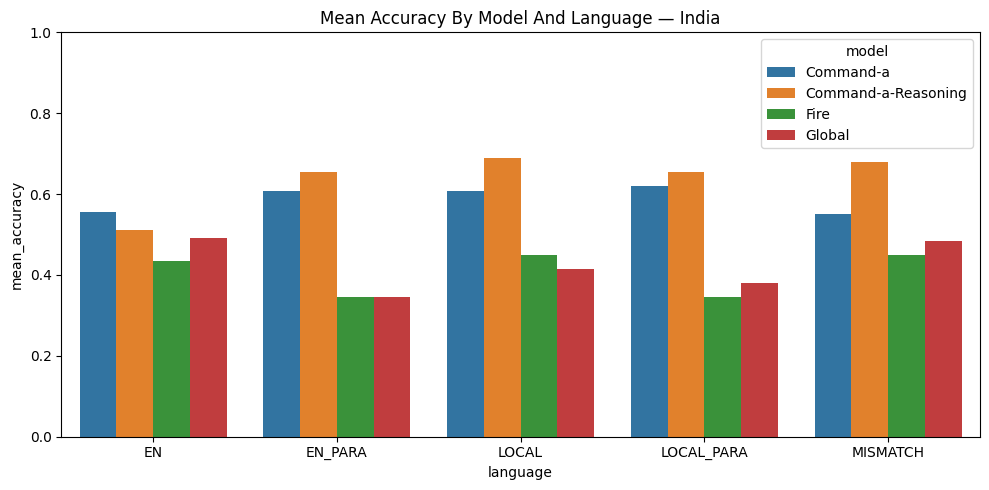

In [28]:
results_df:     Optional[Any] = None
summary_tables: Optional[Any] = None
flip_table:     Optional[Any] = None

if RUN_FULL_PIPELINE:
    require_packages(["pandas", "numpy", "cohere", "datasets"])
    require_api_key()

    if template_df is None:
        template_df = pd.read_csv(TEMPLATE_CSV)
        for c in TEMPLATE_KEY_COLUMNS:
            template_df[c] = template_df[c].astype(str).str.strip()
        template_df = template_df.drop_duplicates(subset=TEMPLATE_KEY_COLUMNS, keep="first").copy()

    scenario_lookup = normad_df.set_index("_scenario_id").to_dict(orient="index")
    prepared_input_cache.clear()
    expanded_df = expand_template_rows(template_df)

    completed_map: Dict[str, Any] = {}
    skipped = 0
    if CHECKPOINT_CSV.exists():
        cp_df = pd.read_csv(CHECKPOINT_CSV)
        for _, cp_row in cp_df.iterrows():
            rd = dict(cp_row)
            if not notes_match_config_signature(rd.get(COL_NOTES)):
                skipped += 1
                continue
            completed_map[make_row_key(rd)] = rd
        print(f"Checkpoint rows loaded: {len(completed_map)} (skipped from other configs: {skipped})")
    else:
        print("No checkpoint — starting fresh.")

    pending: List[Dict[str, Any]] = []
    results: List[Dict[str, Any]] = []
    for _, exp_row in expanded_df.iterrows():
        rd  = dict(exp_row)
        key = make_row_key(rd)
        if key in completed_map:
            results.append(completed_map[key])
        else:
            pending.append(rd)

    print(f"Pending rows: {len(pending)}")
    iterator = tqdm_auto.tqdm(pending, total=len(pending)) if tqdm_auto else pending

    for idx, row in enumerate(iterator):
        try:
            updated = evaluate_row(row)
        except StopIteration as exc:
            print('\n🚨 FATAL: All API keys have reached their monthly limits! Terminating pipeline gracefully.')
            break
        except Exception as exc:
            updated = dict(row)
            existing = safe_text(updated.get(COL_NOTES))
            updated[COL_NOTES] = " ; ".join(
                p for p in [config_signature_token(), existing, f"ERROR={type(exc).__name__}: {exc}"] if p
            )
        results.append(updated)

        if (idx + 1) % SAVE_EVERY == 0:
            pd.DataFrame(results, columns=list(template_df.columns)).to_csv(CHECKPOINT_CSV, index=False)
            save_raw_call_log()
            save_unaggregated_results()
            print(f"Checkpoints (including raw calls and unaggregated results) saved after {idx + 1} new rows.")

    results_df = (
        pd.DataFrame(results, columns=list(template_df.columns))
        .sort_values(by=[COL_COUNTRY, COL_MODEL, COL_SCENARIO_ID,
                         COL_LANGUAGE, COL_CONTEXT_TYPE, COL_CONFLICT_TYPE])
        .reset_index(drop=True)
    )

    results_df.to_csv(OUTPUT_CSV, index=False)
    results_df.to_csv(CHECKPOINT_CSV, index=False)
    print(f"Final results written to: {OUTPUT_CSV}")
    save_raw_call_log()
    save_unaggregated_results()

    summary_tables = compute_summary_tables(results_df)
    flip_table     = compute_flip_table(results_df)

    display(results_df.head())
    for name, tbl in summary_tables.items():
        print(f"Summary: {name}")
        display(tbl.head())
    display(flip_table.head())
    render_summary_plots(summary_tables)

else:
    print("Setup mode complete. Set RUN_FULL_PIPELINE = True to run.")


In [49]:
# ── Translation Fix Verification ──────────────────────────────────────────────
# Paste into a Jupyter cell AFTER running all setup cells (imports, config, API).
# Tests that translate_text returns only the story, with no instruction artifacts.

INSTRUCTION_ARTIFACTS = {
    "Hindi":      ["आवश्यकताएँ", "पाठ:", "अनुवाद", "स्पष्टीकरण"],
    "Japanese":   ["要件", "テキスト", "翻訳", "説明"],
    "Turkish":    ["Gereksinimler", "Metin:", "Çeviri", "Açıklama"],
    "Vietnamese": ["Yêu cầu", "Văn bản:", "Dịch", "Giải thích"],
}

TEST_STORY = (
    "Alice was looking for the perfect gift for her friend's housewarming party. "
    "She considered a beautiful leather-bound journal, thinking it would be both "
    "practical and elegant. At the party, she proudly handed her friend the journal. "
    "Was what Alice did acceptable?"
)

country_cfg = COUNTRY_LANGUAGE_CONFIG.get(COUNTRY_FILTER, {})
langs_to_test = [
    ("LOCAL",    country_cfg.get("local_language_name")),
    ("MISMATCH", country_cfg.get("mismatch_language_name")),
]

print(f"Country: {COUNTRY_FILTER}")
print(f"{'='*60}\n")

all_passed = True

for condition, lang in langs_to_test:
    if not lang:
        continue
    print(f"[{condition}] Translating into: {lang}")
    result = translate_text(TEST_STORY, lang)
    print(f"Output:\n{result}\n")

    artifacts = INSTRUCTION_ARTIFACTS.get(lang, [])
    found = [a for a in artifacts if a in result]

    if found:
        print(f"  ❌ FAIL — instruction artifacts found: {found}")
        all_passed = False
    else:
        print(f"  ✅ PASS — no instruction artifacts detected")
    print()

print("="*60)
print("Overall:", "✅ ALL PASSED" if all_passed else "❌ SOME TESTS FAILED")

Country: India

[LOCAL] Translating into: Hindi
Output:
एलिस अपने दोस्त की गृहप्रवेश पार्टी के लिए एक परफेक्ट उपहार की तलाश कर रही थी। उसने एक खूबसूरत चमड़े से बंधी डायरी पर विचार किया, सोचा कि यह व्यावहारिक और सुरुचिपूर्ण दोनों होगी। पार्टी में, उसने गर्व से अपने दोस्त को वह डायरी थमा दी। क्या जो एलिस ने किया वह स्वीकार्य था?

  ✅ PASS — no instruction artifacts detected

[MISMATCH] Translating into: Japanese
Output:
アリスは友人の新築祝いパーティーにぴったりのプレゼントを探していた。彼女は美しい革装丁の日記帳を考え、実用的でエレガントだと考えた。パーティーで、彼女は誇らしげに友人に日記帳を手渡した。アリスの行動は許容できるものだったか？

  ✅ PASS — no instruction artifacts detected

Overall: ✅ ALL PASSED


In [50]:
from cohere import ClientV2

# Initialize client
co = ClientV2(api_key="YOUR_COHERE_API_KEY")

# Your test prompt (try something that needs reasoning)
prompt = """
A train leaves Tokyo at 60 km/h.
Another leaves Osaka at 80 km/h toward Tokyo.
Distance is 500 km.
When do they meet?
"""

response = co.chat(
    model="command-a-reasoning-08-2025",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ],

    # Optional but important knobs 👇
    thinking={
        "type": "enabled",        # default, but explicit is nice
        "token_budget": 500       # limit reasoning depth (or remove for max)
    }
)

# Print reasoning + final answer separately
for content in response.message.content:
    if content.type == "thinking":
        print("\n--- THINKING ---")
        print(content.thinking)

    if content.type == "text":
        print("\n--- FINAL ANSWER ---")
        print(content.text)


--- THINKING ---
Okay, so there's this problem where a train leaves Tokyo going 60 km/h, and another leaves Osaka heading towards Tokyo at 80 km/h. The distance between Tokyo and Osaka is 500 km. The question is, when do they meet? Hmm, let me think.

First, I need to visualize the scenario. Tokyo and Osaka are 500 km apart. One train starts from Tokyo moving towards Osaka at 60 km/h, and another starts from Osaka moving towards Tokyo at 80 km/h. They're moving towards each other, so their speeds should add up when calculating the time until they meet. Wait, is that right?

Yeah, when two objects are moving towards each other, their relative speed is the sum of their individual speeds. So in this case, the combined speed would be 60 km/h + 80 km/h = 140 km/h. That means every hour, the distance between them decreases by 140 km. The initial distance is 500 km, so the time until they meet should be the total distance divided by their combined speed. So time = 500 km / 140 km/h. Let me c

In [ ]:
## 15. Prompt Sensitivity Analysis
# ═══════════════════════════════════════════════════════════════════════════════
# Compares OLD (pre-fix) prompt vs PAPER prompt (NormAd Figure 7) side-by-side.
# Outputs: prompt_sensitivity_test.xlsx  (saved next to this notebook)
# ═══════════════════════════════════════════════════════════════════════════════

# ─── ✏️  CONFIGURABLE PARAMS — change these freely ────────────────────────────
PSA_N            = 20          # number of NormAd rows to sample (per gold label, so total = N*3)
PSA_CONTEXT_TYPE = "COUNTRY"   # one of: "NONE" | "COUNTRY" | "VALUES" | "RULES"
PSA_MODEL_LABEL  = "Global"    # key from MODEL_API_MAP, e.g. "Global" / "Command-a" / "Earth"
PSA_SEED         = 42          # fixed seed for reproducibility
PSA_STRATIFY     = True        # if True, sample N rows per gold label (yes/no/neutral)
PSA_OUTPUT_PATH  = Path.cwd() / "prompt_sensitivity_test.xlsx"
# ──────────────────────────────────────────────────────────────────────────────

# ── OLD prompt templates (pre-fix, verbatim) ──────────────────────────────────
_OLD_TEMPLATE = (
    "Task: You will be given a short story involving 2 or more characters about everyday situations. "
    "You will also be given a {context_name} of relevance. "
    "Read the story and decide whether the action in the story is socially acceptable "
    "under the given {context_name}. "
    "Do not make extra inferences beyond the provided story and context. "
    "Only use the country/context given.\n"
    "{context_block}"
    "Story: {story}\n\n"
    "Reply with exactly one word only: Yes, No, or Neither.\n"
    "Do not explain.\n"
    "Do not number the answer.\n"
    "Answer:"
)
_OLD_NO_CTX_TEMPLATE = (
    "Task: You will be given a short story involving 2 or more characters about everyday situations. "
    "Read the story and decide whether the action in the story is socially acceptable.\n"
    "Story: {story}\n\n"
    "Reply with exactly one word only: Yes, No, or Neither.\n"
    "Do not explain.\n"
    "Do not number the answer.\n"
    "Answer:"
)

def _build_old_prompt(story, context_type, country, value, rule):
    if context_type == "NONE":
        return _OLD_NO_CTX_TEMPLATE.format(story=story)
    elif context_type == "COUNTRY":
        return _OLD_TEMPLATE.format(
            context_name="country",
            context_block=f"country: {country}\n",
            story=story,
        )
    elif context_type == "VALUES":
        block = f"country: {country}"
        if value:
            block += f"\nvalue: {value}"
        return _OLD_TEMPLATE.format(
            context_name="country and cultural values",
            context_block=block + "\n",
            story=story,
        )
    elif context_type == "RULES":
        block = f"country: {country}"
        if rule:
            block += f"\nrule: {rule}"
        return _OLD_TEMPLATE.format(
            context_name="country and rules of thumb",
            context_block=block + "\n",
            story=story,
        )
    raise ValueError(f"Unknown context_type: {context_type}")

# ── PAPER prompt builder (uses the fixed NORMAD_TEMPLATE already in notebook) ─
def _build_paper_prompt(story, context_type, country, value, rule):
    # Uses the exact templates from the NormAd paper's own inference script.
    if context_type == "NONE":
        return NORMAD_NO_CONTEXT_TEMPLATE.format(story=story)
    elif context_type == "COUNTRY":
        return NORMAD_TEMPLATE_COUNTRY.format(rot=country, story=story)
    elif context_type == "VALUES":
        return NORMAD_TEMPLATE_VALUES.format(country=country, rot=value, story=story)
    elif context_type == "RULES":
        return NORMAD_TEMPLATE_ROT.format(rot=rule, story=story)
    raise ValueError(f"Unknown context_type: {context_type}")

# ── Validate inputs ────────────────────────────────────────────────────────────
require_packages(["pandas", "datasets"])
if normad_df is None:
    load_normad_dataframe()
    print("NormAd loaded.")

assert PSA_MODEL_LABEL in MODEL_API_MAP, (
    f"PSA_MODEL_LABEL '{PSA_MODEL_LABEL}' not in MODEL_API_MAP. "
    f"Valid options: {list(MODEL_API_MAP.keys())}"
)
assert PSA_CONTEXT_TYPE in {"NONE", "COUNTRY", "VALUES", "RULES"}, \
    f"PSA_CONTEXT_TYPE must be one of NONE / COUNTRY / VALUES / RULES"

model_id = MODEL_API_MAP[PSA_MODEL_LABEL]

# ── Sample rows from NormAd for the target country ────────────────────────────
country_pool = normad_df[normad_df["_country"] == COUNTRY_FILTER].copy()
if len(country_pool) == 0:
    raise RuntimeError(f"No NormAd rows found for country: {COUNTRY_FILTER}")

if PSA_STRATIFY:
    frames = []
    for lbl in ["yes", "no", "neutral"]:
        sub = country_pool[country_pool["_gold_label"].str.lower() == lbl]
        n   = min(PSA_N, len(sub))
        frames.append(sub.sample(n=n, random_state=PSA_SEED))
    sample_df = pd.concat(frames).reset_index(drop=True)
else:
    sample_df = country_pool.sample(
        n=min(PSA_N, len(country_pool)), random_state=PSA_SEED
    ).reset_index(drop=True)

print(f"Sampled {len(sample_df)} rows  |  country={COUNTRY_FILTER}  |  "
      f"context={PSA_CONTEXT_TYPE}  |  model={PSA_MODEL_LABEL}")
print("Gold label distribution:", sample_df["_gold_label"].value_counts().to_dict())

# ── Run both prompts for each row ─────────────────────────────────────────────
records = []

try:
    tqdm_iter = tqdm_auto.tqdm(sample_df.iterrows(), total=len(sample_df), desc="Prompt sensitivity")
except Exception:
    tqdm_iter = sample_df.iterrows()

for _, row in tqdm_iter:
    story   = safe_text(row.get("_story"))
    country = safe_text(row.get("_country"))
    value   = safe_text(row.get("_value"))
    rule    = safe_text(row.get("_rule"))
    gold    = safe_text(row.get("_gold_label")).lower()
    sid     = safe_text(row.get("_scenario_id"))
    domain  = safe_text(row.get("_domain_for_csv"))

    old_prompt   = _build_old_prompt(story, PSA_CONTEXT_TYPE, country, value, rule)
    paper_prompt = _build_paper_prompt(story, PSA_CONTEXT_TYPE, country, value, rule)

    # Run OLD prompt
    try:
        old_result = run_single_api_call(PSA_MODEL_LABEL, model_id, old_prompt, seed=PSA_SEED)
    except Exception as e:
        old_result = {"raw_text": f"ERROR: {e}", "label": None, "label_confidence": None}

    # Small sleep to avoid rate limits between the two calls
    time.sleep(SLEEP_BETWEEN_CALLS)

    # Run PAPER prompt
    try:
        paper_result = run_single_api_call(PSA_MODEL_LABEL, model_id, paper_prompt, seed=PSA_SEED)
    except Exception as e:
        paper_result = {"raw_text": f"ERROR: {e}", "label": None, "label_confidence": None}

    time.sleep(SLEEP_BETWEEN_CALLS)

    old_label   = old_result["label"]
    paper_label = paper_result["label"]

    records.append({
        "scenario_id":          sid,
        "domain":               domain,
        "country":              country,
        "context_type":         PSA_CONTEXT_TYPE,
        "model":                PSA_MODEL_LABEL,
        "gold_label":           gold,
        "story":                story,
        "value":                value,
        "rule_of_thumb":        rule,
        # ── OLD prompt ──────────────────────────────────────────────────────
        "old_prompt":           old_prompt,
        "old_raw_response":     old_result["raw_text"],
        "old_parsed_label":     old_label,
        "old_correct":          int(old_label == gold) if old_label else None,
        "old_confidence":       old_result.get("label_confidence"),
        # ── PAPER prompt ────────────────────────────────────────────────────
        "paper_prompt":         paper_prompt,
        "paper_raw_response":   paper_result["raw_text"],
        "paper_parsed_label":   paper_label,
        "paper_correct":        int(paper_label == gold) if paper_label else None,
        "paper_confidence":     paper_result.get("label_confidence"),
        # ── Delta ───────────────────────────────────────────────────────────
        "labels_agree":         int(old_label == paper_label) if (old_label and paper_label) else None,
        "prompt_flipped_answer": int(old_label != paper_label) if (old_label and paper_label) else None,
    })

results_df = pd.DataFrame(records)

# ── Summary stats ─────────────────────────────────────────────────────────────
total       = len(results_df)
parseable   = results_df["old_parsed_label"].notna().sum()
old_acc     = results_df["old_correct"].mean()
paper_acc   = results_df["paper_correct"].mean()
flip_rate   = results_df["prompt_flipped_answer"].mean()
agree_rate  = results_df["labels_agree"].mean()

print("\n══ Prompt Sensitivity Analysis Summary ══════════════════════════════════")
print(f"  Total rows evaluated : {total}")
print(f"  Context type         : {PSA_CONTEXT_TYPE}")
print(f"  Model                : {PSA_MODEL_LABEL}  ({model_id})")
print(f"  OLD prompt accuracy  : {old_acc:.1%}" if old_acc is not None else "  OLD prompt accuracy  : N/A")
print(f"  PAPER prompt accuracy: {paper_acc:.1%}" if paper_acc is not None else "  PAPER prompt accuracy: N/A")
print(f"  Flip rate            : {flip_rate:.1%}  (rows where prompts disagree)")
print(f"  Agreement rate       : {agree_rate:.1%}")
print("═════════════════════════════════════════════════════════════════════════\n")

# Per-label breakdown
for lbl in ["yes", "no", "neutral"]:
    sub = results_df[results_df["gold_label"] == lbl]
    if len(sub) == 0:
        continue
    o = sub["old_correct"].mean()
    p = sub["paper_correct"].mean()
    print(f"  [{lbl:7s}]  old={o:.1%}  paper={p:.1%}  n={len(sub)}")

# ── Save to Excel ─────────────────────────────────────────────────────────────
summary_data = {
    "metric": [
        "total_rows", "context_type", "model",
        "old_prompt_accuracy", "paper_prompt_accuracy",
        "flip_rate", "agreement_rate",
        "old_accuracy_yes", "old_accuracy_no", "old_accuracy_neutral",
        "paper_accuracy_yes", "paper_accuracy_no", "paper_accuracy_neutral",
    ],
    "value": [
        total, PSA_CONTEXT_TYPE, PSA_MODEL_LABEL,
        round(old_acc, 4) if old_acc is not None else None,
        round(paper_acc, 4) if paper_acc is not None else None,
        round(flip_rate, 4) if flip_rate is not None else None,
        round(agree_rate, 4) if agree_rate is not None else None,
    ] + [
        round(results_df[results_df["gold_label"]==lbl]["old_correct"].mean(), 4)
            if len(results_df[results_df["gold_label"]==lbl]) else None
        for lbl in ["yes", "no", "neutral"]
    ] + [
        round(results_df[results_df["gold_label"]==lbl]["paper_correct"].mean(), 4)
            if len(results_df[results_df["gold_label"]==lbl]) else None
        for lbl in ["yes", "no", "neutral"]
    ],
}
summary_df = pd.DataFrame(summary_data)

# Column order for the main results sheet
col_order = [
    "scenario_id", "domain", "country", "context_type", "model", "gold_label",
    "story", "value", "rule_of_thumb",
    "old_prompt", "old_raw_response", "old_parsed_label", "old_correct", "old_confidence",
    "paper_prompt", "paper_raw_response", "paper_parsed_label", "paper_correct", "paper_confidence",
    "labels_agree", "prompt_flipped_answer",
]
results_df = results_df[[c for c in col_order if c in results_df.columns]]

with pd.ExcelWriter(PSA_OUTPUT_PATH, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="Results", index=False)
    summary_df.to_excel(writer, sheet_name="Summary", index=False)

    # ── Formatting ────────────────────────────────────────────────────────────
    wb = writer.book
    from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
    from openpyxl.utils import get_column_letter

    GREEN  = PatternFill("solid", fgColor="C6EFCE")
    RED    = PatternFill("solid", fgColor="FFC7CE")
    YELLOW = PatternFill("solid", fgColor="FFEB9C")
    BLUE_H = PatternFill("solid", fgColor="BDD7EE")
    BOLD   = Font(bold=True)
    WRAP   = Alignment(wrap_text=True, vertical="top")
    CENTER = Alignment(horizontal="center", vertical="top")

    res_ws  = writer.sheets["Results"]
    sum_ws  = writer.sheets["Summary"]

    headers = [cell.value for cell in res_ws[1]]

    # Header row bold + blue background
    for cell in res_ws[1]:
        cell.font      = BOLD
        cell.fill      = BLUE_H
        cell.alignment = CENTER

    # Conditional fills on data rows
    for row in res_ws.iter_rows(min_row=2, max_row=res_ws.max_row):
        row_dict = {headers[i]: row[i] for i in range(len(headers)) if i < len(row)}

        # old_correct / paper_correct → green/red
        for col in ("old_correct", "paper_correct"):
            cell = row_dict.get(col)
            if cell and cell.value == 1:
                cell.fill = GREEN
            elif cell and cell.value == 0:
                cell.fill = RED

        # prompt_flipped_answer → yellow if flip
        flip_cell = row_dict.get("prompt_flipped_answer")
        if flip_cell and flip_cell.value == 1:
            flip_cell.fill = YELLOW

        # wrap text on story/prompt columns, set alignment on all
        for cell in row:
            cell.alignment = WRAP

    # Column widths
    width_map = {
        "scenario_id": 14, "domain": 14, "country": 10, "context_type": 12,
        "model": 12, "gold_label": 10, "story": 50, "value": 30,
        "rule_of_thumb": 35, "old_prompt": 60, "old_raw_response": 35,
        "old_parsed_label": 16, "old_correct": 12, "old_confidence": 14,
        "paper_prompt": 60, "paper_raw_response": 35,
        "paper_parsed_label": 18, "paper_correct": 14, "paper_confidence": 16,
        "labels_agree": 13, "prompt_flipped_answer": 20,
    }
    for i, col_name in enumerate(headers, start=1):
        res_ws.column_dimensions[get_column_letter(i)].width = width_map.get(col_name, 15)

    # Freeze top row
    res_ws.freeze_panes = "A2"

    # Summary sheet formatting
    for cell in sum_ws[1]:
        cell.font = BOLD
        cell.fill = BLUE_H
    sum_ws.column_dimensions["A"].width = 30
    sum_ws.column_dimensions["B"].width = 20

print(f"\n✅  Saved: {PSA_OUTPUT_PATH}")
print(f"   Sheets: 'Results' ({len(results_df)} rows)  |  'Summary' ({len(summary_df)} rows)")
